In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tabulate
import math
import numpy as np
import pingouin as pg

## Load Data Set

In [2]:
#from github
username = "StefanFSmid"
repository = "ASDA_2025_Group_3_Porfolio"
directory = "48-hour-exam/group_3_faa_data_subset/group_3_faa_data_subset/faa_data_subset.xlsx"

github_url = f"https://raw.githubusercontent.com/{username}/{repository}/master/{directory}"
df = pd.read_excel(github_url)


## Basic Data Inspection and Cleaning

In [3]:
# Display the shape of the dataframe
df.shape

(28298, 25)

In [4]:
# Display the info of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28298 entries, 0 to 28297
Data columns (total 25 columns):
 #   Column                                      Non-Null Count  Dtype         
---  ------                                      --------------  -----         
 0   Airport: Code                               28298 non-null  object        
 1   Airport: Name                               28298 non-null  object        
 2   Origin State                                28298 non-null  object        
 3   Origin State Code                           28298 non-null  object        
 4   Country                                     28298 non-null  object        
 5   Aircraft: Type                              27467 non-null  object        
 6   Aircraft: Number of engines                 25918 non-null  float64       
 7   Collision Date and Time                     28298 non-null  datetime64[ns]
 8   When: Time of day                           27655 non-null  object        
 9   When: 

In [5]:
# Display the first few rows of the dataframe
df.head()

,Airport: Code,Airport: Name,Origin State,Origin State Code,Country,Aircraft: Type,Aircraft: Number of engines,Collision Date and Time,When: Time of day,When: Phase of flight,...,Days,Feet above ground,Miles from airport,Wildlife: Animal Category,Wildlife: Species Order,Wildlife: Species Group,Wildlife: Species,Wildlife: Species ID,Number of Strikes,Record ID
0,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,NaN,NaN,2012-09-20 19:30:00,NaN,Take-off run,...,NaN,0.0,NaN,Terrestrial Mammals,Canids,"Wolves, Dogs, Foxes, Coyote",Domestic dog,1F12,1,17459
1,KAAF,APALACHICOLA REGIONAL ARPT,Florida,FL,United States,Airplane,1.0,2013-04-23 17:09:00,NaN,Take-off run,...,NaN,NaN,NaN,Birds,"Pelicans, Herons, Egrets, Bitterns, Ibises","Herons, Egrets, Bitterns","Herons, egrets, bitterns",I1,1,17114
2,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-04-23 09:22:00,Day,Take-off run,...,30.000,0.0,0.0,Birds,"Caracaras, Falcons","Caracaras, Falcons",American kestrel,K5114,1,259361
3,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2014-04-13 22:00:00,Night,Approach,...,0.625,NaN,NaN,Birds,Pigeons and Doves,Doves,Mourning dove,O2205,1,345167
4,KABE,LEHIGH VALLEY INTL,Pennsylvania,PA,United States,Airplane,2.0,2009-03-31 18:15:00,Day,Approach,...,0.500,NaN,0.0,Birds,"Hawks, Kites, Eagles, Ospreys, Vultures","Kites, Hawks, Eagles",Red-tailed hawk,K3302,1,262782


In [6]:
# Display the summary statistics of the dataframe
df.describe().round(0)

,Aircraft: Number of engines,Collision Date and Time,Cost: Aircraft time out of service (hours),Cost: Total $,Days,Feet above ground,Miles from airport,Number of Strikes,Record ID
count,25918.0,28298,2929.0,28298.0,2929.0,24872.0,19807.0,28298.0,28298.0
mean,2.0,2009-08-02 02:55:58.905929728,85.0,11385.0,4.0,339.0,0.0,1.0,271474.0
min,1.0,2000-01-02 10:27:00,0.0,0.0,0.0,0.0,0.0,1.0,1164.0
25%,2.0,2006-07-21 11:55:00,1.0,0.0,0.0,0.0,0.0,1.0,235364.0
50%,2.0,2010-07-17 07:42:00,2.0,0.0,0.0,0.0,0.0,1.0,301697.0
75%,2.0,2013-01-27 07:36:15,24.0,0.0,1.0,100.0,0.0,1.0,330425.0
max,4.0,2015-05-31 21:47:00,21000.0,41071585.0,875.0,20000.0,100.0,1.0,360842.0
std,0.0,NaN,509.0,312536.0,21.0,1065.0,3.0,0.0,81859.0


In [7]:
# display missing values

missing_values = df.isnull().sum()
missing_values_percentage = (missing_values / len(df)) * 100
missing_values_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_values_percentage})
missing_values_df = missing_values_df[missing_values_df['Missing Values'] > 0]
missing_values_df = missing_values_df.sort_values(by='Missing Values', ascending=False)
print(tabulate.tabulate(missing_values_df, headers='keys', tablefmt='psql'))


+--------------------------------------------+------------------+--------------+
|                                            |   Missing Values |   Percentage |
|--------------------------------------------+------------------+--------------|
| Cost: Aircraft time out of service (hours) |            25369 |     89.6494  |
| Days                                       |            25369 |     89.6494  |
| Effect: Impact to flight                   |            25265 |     89.2819  |
| Effect: Amount of damage (detailed)        |            25187 |     89.0063  |
| Miles from airport                         |             8491 |     30.0057  |
| Feet above ground                          |             3426 |     12.1069  |
| Aircraft: Number of engines                |             2380 |      8.41049 |
| Aircraft: Type                             |              831 |      2.9366  |
| When: Time of day                          |              643 |      2.27225 |
| When: Phase of flight     

In [8]:
df.columns = (
    df.columns
      .str.replace('$', '', regex=False)
      .str.strip()
      .str.lower()
      .str.replace(':', '', regex=False)  
      .str.replace('(', '', regex=False)
      .str.replace(')', '', regex=False)
      .str.replace(' ', '_', regex=False)
)

# Print the cleaned column names
print(df.columns)


Index(['airport_code', 'airport_name', 'origin_state', 'origin_state_code',
       'country', 'aircraft_type', 'aircraft_number_of_engines',
       'collision_date_and_time', 'when_time_of_day', 'when_phase_of_flight',
       'effect_amount_of_damage_detailed', 'effect_impact_to_flight',
       'effect_indicated_damage', 'cost_aircraft_time_out_of_service_hours',
       'cost_total', 'days', 'feet_above_ground', 'miles_from_airport',
       'wildlife_animal_category', 'wildlife_species_order',
       'wildlife_species_group', 'wildlife_species', 'wildlife_species_id',
       'number_of_strikes', 'record_id'],
      dtype='object')


In [9]:
#Check for duplicates
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")

Number of duplicate rows: 0


## ANOVA Analysis

#### RQ1: Does altitude differ across phases of flight?
Whether the height at which a wildlife strike occurs changes depending on what the aircraft is doing at the time — takeoff, landing, climb, approach, etc. The idea is that different flight phases happen at different altitudes, and birds or wildlife may be more concentrated at certain heights. If significant differences exist, it tells us which flight phases are more dangerous in terms of strike altitude, which can inform safety protocols.

#### RQ2: Does altitude differ across times of day?
Whether wildlife strikes happen at different altitudes depending on the time of day. Wildlife behavior changes throughout the day — birds tend to fly at different heights during migration at night versus feeding during the day. If altitude differs significantly by time of day, it suggests that wildlife activity patterns at certain hours pose risks at specific heights, which can help airports adjust flight schedules or issue altitude-based warnings at certain times.

#### RQ3: Does distance from airport differ across phases of flight?
Whether how far from the airport a strike occurs depends on the flight phase. For example, strikes during approach or landing would be expected closer to the airport, while strikes during cruise would be farther away. If significant differences are found, it helps airports understand the geographic range of the wildlife strike risk and whether safety measures should focus close to the airport or extend further out along flight paths.


In [10]:

from scipy import stats
from pingouin import pairwise_gameshowell


In [15]:
#ANOVA → Games-Howell → Residuals

def run_anova(numeric_col, group_col, df, rq_title):
    print("=" * 60)
    print(f"Research Question: {rq_title}")
    print(f"Testing '{numeric_col}' across '{group_col}'")
    print("=" * 60)

    # Drop missing values
    data = df[[numeric_col, group_col]].dropna()
    groups = [group[numeric_col].values
              for name, group in data.groupby(group_col)]

    # ── Step 1: One-Way ANOVA ──
    f_stat, p_value = stats.f_oneway(*groups)
    print(f"\nOne-Way ANOVA: F = {f_stat:.4f}, p = {p_value:.4f}")

    if p_value >= 0.05:
        print("→ No significant difference between groups (p >= 0.05)")
        print("→ Post-hoc test not needed.\n")
        return

    print("→ Significant difference found (p < 0.05) → running Games-Howell\n")

    # ── Step 2: Games-Howell Post-hoc ──
    gh = pairwise_gameshowell(data=data,
                              dv=numeric_col,
                              between=group_col)
    print("Games-Howell Results:")
    print(gh.to_string(index=False))

    # ── Step 3: Box plot ──
    group_names = sorted(data[group_col].unique())
    groups_data = [data[data[group_col] == name][numeric_col].values
                   for name in group_names]

    plt.figure(figsize=(10, 5))
    plt.boxplot(groups_data, labels=group_names)
    plt.ylabel(numeric_col)
    plt.title(rq_title)
    plt.xticks(rotation=20, ha='right')
    plt.tight_layout()
    plt.show()

    # ── Step 4: Residuals ──
    print("\n── Residuals Analysis ──")

    group_means = data.groupby(group_col)[numeric_col].transform('mean')
    residuals   = data[numeric_col] - group_means

    print(f"   Mean    : {residuals.mean():.4f}  (should be ~0)")
    print(f"   Std Dev : {residuals.std():.4f}")
    print(f"   Min     : {residuals.min():.4f}")
    print(f"   Max     : {residuals.max():.4f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(residuals, bins=40, color='steelblue', edgecolor='white')
    axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5)
    axes[0].set_xlabel("Residual")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(f"Residuals Histogram\n{rq_title}")

    stats.probplot(residuals, dist="norm", plot=axes[1])
    axes[1].set_title(f"Q-Q Plot of Residuals\n{rq_title}")

    plt.tight_layout()
    plt.show()
    print()


Research Question: RQ1: Does altitude differ across phases of flight?
Testing 'feet_above_ground' across 'when_phase_of_flight'

One-Way ANOVA: F = 1181.6317, p = 0.0000
→ Significant difference found (p < 0.05) → running Games-Howell



/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pingouin/pairwise.py:1058: RuntimeWarning: divide by zero encountered in divide
  tval = mn / np.sqrt(gvars[g1] / n[g1] + gvars[g2] / n[g2])
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pingouin/pairwise.py:1059: RuntimeWarning: invalid value encountered in divide
  df = (gvars[g1] / n[g1] + gvars[g2] / n[g2]) ** 2 / (
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pingouin/effsize.py:803: RuntimeWarning: divide by zero encountered in scalar divide
  d = (x.mean() - y.mean()) / poolsd


Games-Howell Results:
           A            B      mean(A)      mean(B)         diff         se            T           df         pval      hedges
    Approach        Climb   715.475275   670.566223    44.909052  31.225876     1.438200  4318.764876 9.152583e-01    0.034843
    Approach    Departure   715.475275 10000.000000 -9284.524725  13.832559  -671.208025  7542.000000 1.437628e-12   -7.728064
    Approach      Descent   715.475275  5913.029412 -5197.554137 285.191386   -18.224794   169.797943 1.032507e-14   -3.969678
    Approach      Landing   715.475275    88.552795   626.922480  29.845222    21.005790   259.108677 4.551914e-15    0.526861
    Approach Landing Roll   715.475275     4.222282   711.252993  13.874921    51.261769  7634.523608 1.889267e-12    0.832643
    Approach        Local   715.475275   362.500000   352.975275 134.724237     2.619983    11.235637 3.071769e-01    0.293965
    Approach       Parked   715.475275     0.000000   715.475275  13.832559    51.723999 

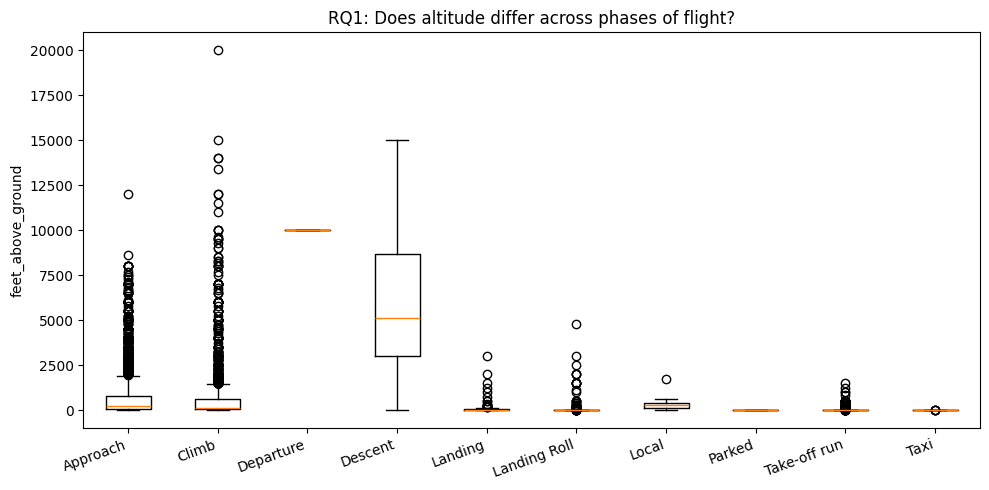


── Residuals Analysis ──
   Mean    : 0.0000  (should be ~0)
   Std Dev : 890.9463
   Min     : -5903.0294
   Max     : 19329.4338


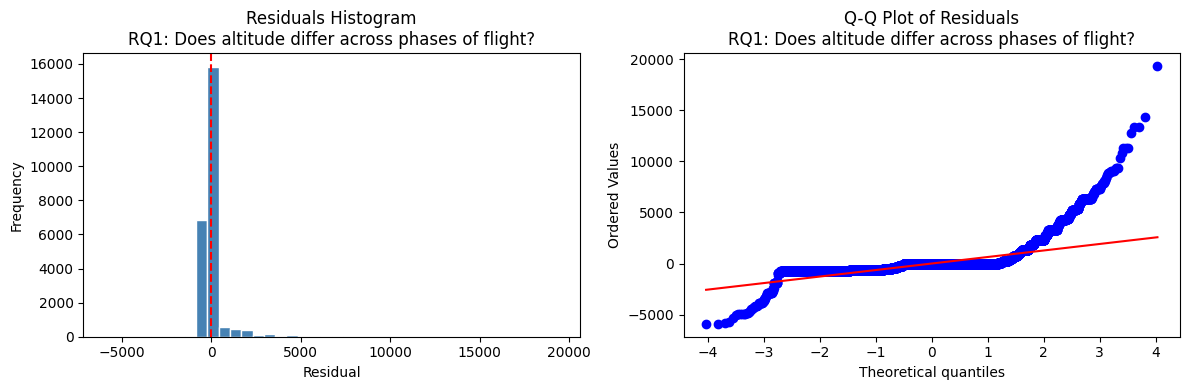

In [ ]:
# RQ1: Does altitude differ across phases of flight?

run_anova('feet_above_ground', 'when_phase_of_flight', df,
          'RQ1: Does altitude differ across phases of flight?')

#### Observations:
•	Descent has by far the highest altitude with a wide spread (median ~5000 feet, range up to 15000 feet), which makes perfect sense as the aircraft is coming down from cruise altitude

•	Departure shows only one data point at ~10000 feet, suggesting very few strikes during this phase

•	Climb has a low median but many high outliers reaching up to 20000 feet, meaning most strikes happen low but some occur very high

•	Approach, Landing, Landing Roll, Taxi, Take-off run all cluster near 0 feet, confirming these phases happen close to the ground

•	Parked is flat at 0 which is expected — the aircraft is on the ground

#### Conclusion: 
Altitude differs significantly across flight phases. Descent and Climb phases involve strikes at much higher altitudes compared to ground-level phases like Landing, Taxi, and Take-off run. This confirms that different flight phases carry different altitude-related wildlife strike risks.


Research Question: RQ2: Does altitude differ across times of day?
Testing 'feet_above_ground' across 'when_time_of_day'

One-Way ANOVA: F = 866.3378, p = 0.0000
→ Significant difference found (p < 0.05) → running Games-Howell

Games-Howell Results:
   A     B    mean(A)     mean(B)        diff        se          T          df         pval    hedges
Dawn   Day 171.304910  189.165430  -17.860520 21.774457  -0.820251  887.412780 8.449072e-01 -0.023640
Dawn  Dusk 171.304910  198.743403  -27.438494 29.706101  -0.923665 1812.770096 7.921887e-01 -0.042059
Dawn Night 171.304910 1076.598498 -905.293588 35.427894 -25.553130 3811.399959 2.421729e-12 -0.533484
 Day  Dusk 189.165430  198.743403   -9.577973 21.717690  -0.441022 1261.342546 9.713290e-01 -0.012632
 Day Night 189.165430 1076.598498 -887.433068 29.057552 -30.540531 4452.286210 0.000000e+00 -0.849959
Dusk Night 198.743403 1076.598498 -877.855095 35.393033 -24.803048 4664.857320 0.000000e+00 -0.529232


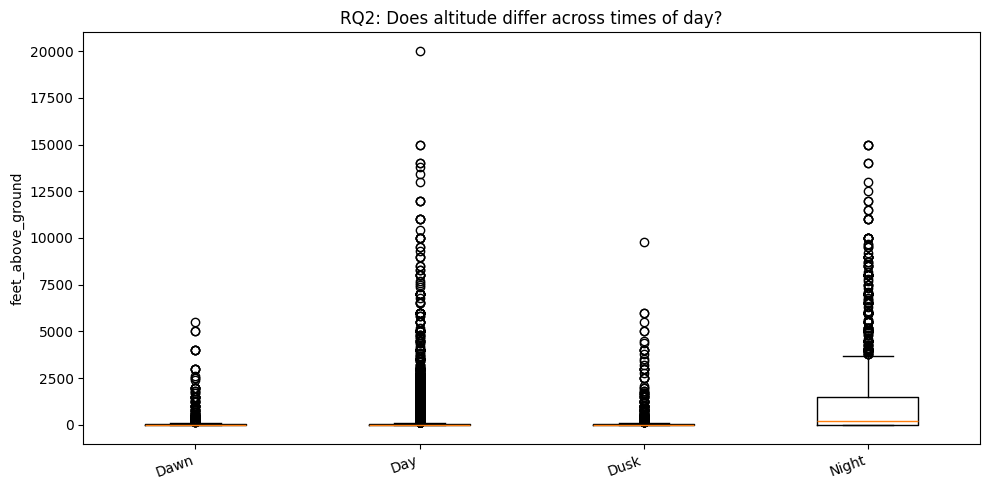


── Residuals Analysis ──
   Mean    : 0.0000  (should be ~0)
   Std Dev : 1019.2080
   Min     : -1076.5985
   Max     : 19810.8346


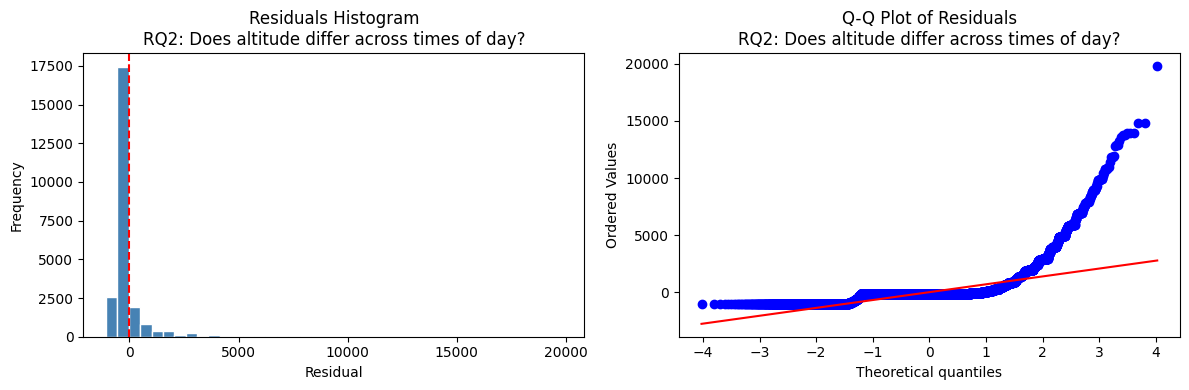

In [17]:
# RQ2: Does altitude differ across times of day?

run_anova('feet_above_ground', 'when_time_of_day', df,
          'RQ2: Does altitude differ across times of day?')

#### Observations:
•	Night stands out clearly — it has a noticeably higher median altitude (around 1000–1500 feet) and a much larger interquartile range compared to all other time periods

•	Dawn, Day, and Dusk all have medians close to 0, meaning most strikes during these times happen near ground level

•	Day has the most outliers reaching up to 20000 feet, simply because there are far more flights during the day

•	Dusk has a few moderate outliers up to ~10000 feet but remains mostly low

#### Conclusion:
Altitude differs significantly across times of day. Night strikes occur at notably higher altitudes than dawn, day, and dusk strikes. This likely reflects that night flights tend to be at cruising altitude when wildlife — particularly migratory birds — are also flying at higher elevations, creating a higher-altitude collision risk.


Research Question: RQ3: Does distance from airport differ across phases of flight?
Testing 'miles_from_airport' across 'when_phase_of_flight'

One-Way ANOVA: F = 665.4659, p = 0.0000
→ Significant difference found (p < 0.05) → running Games-Howell



/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pingouin/pairwise.py:1058: RuntimeWarning: invalid value encountered in divide
  tval = mn / np.sqrt(gvars[g1] / n[g1] + gvars[g2] / n[g2])
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pingouin/pairwise.py:1059: RuntimeWarning: invalid value encountered in divide
  df = (gvars[g1] / n[g1] + gvars[g2] / n[g2]) ** 2 / (
/Library/Frameworks/Python.framework/Versions/3.9/lib/python3.9/site-packages/pingouin/effsize.py:803: RuntimeWarning: invalid value encountered in scalar divide
  d = (x.mean() - y.mean()) / poolsd


Games-Howell Results:
           A            B   mean(A)   mean(B)       diff       se          T          df         pval    hedges
    Approach      Arrival  1.732219  0.000000   1.732219 0.062681  27.635364 3902.000000 1.260436e-12  0.442945
    Approach        Climb  1.732219  0.851765   0.880453 0.126788   6.944274 2525.753940 2.660890e-10  0.219132
    Approach    Departure  1.732219  0.714286   1.017933 0.717031   1.419651   27.417429 9.327184e-01  0.259957
    Approach      Descent  1.732219 18.452055 -16.719836 1.357566 -12.316038   72.307962 4.440892e-15 -3.997291
    Approach      Landing  1.732219  0.500000   1.232219 0.503914   2.445298    1.031678 6.254361e-01  0.314645
    Approach Landing Roll  1.732219  0.000000   1.732219 0.062681  27.635364 3902.000000 1.260436e-12  0.756109
    Approach        Local  1.732219  0.000000   1.732219 0.062681  27.635364 3902.000000 1.260436e-12  0.443962
    Approach       Parked  1.732219  0.000000   1.732219 0.062681  27.635364 3902.

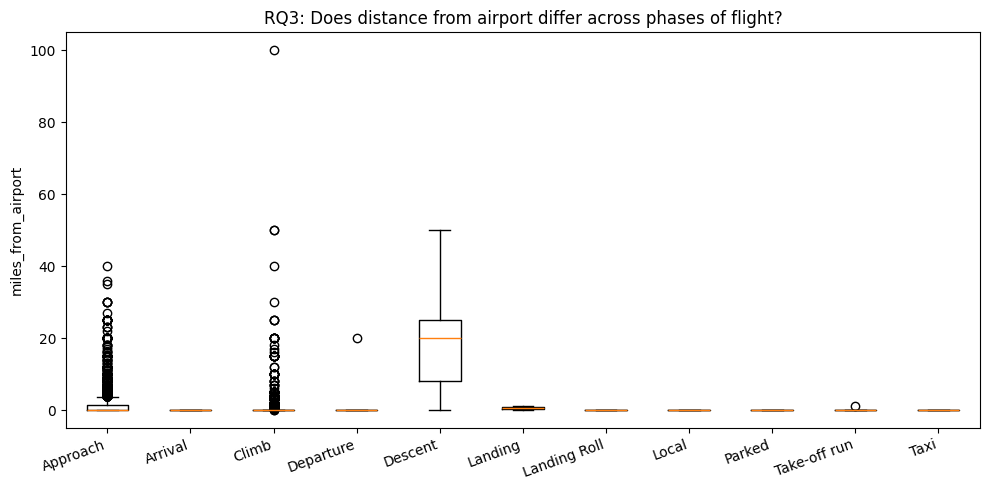


── Residuals Analysis ──
   Mean    : 0.0000  (should be ~0)
   Std Dev : 2.2310
   Min     : -18.4521
   Max     : 99.1482


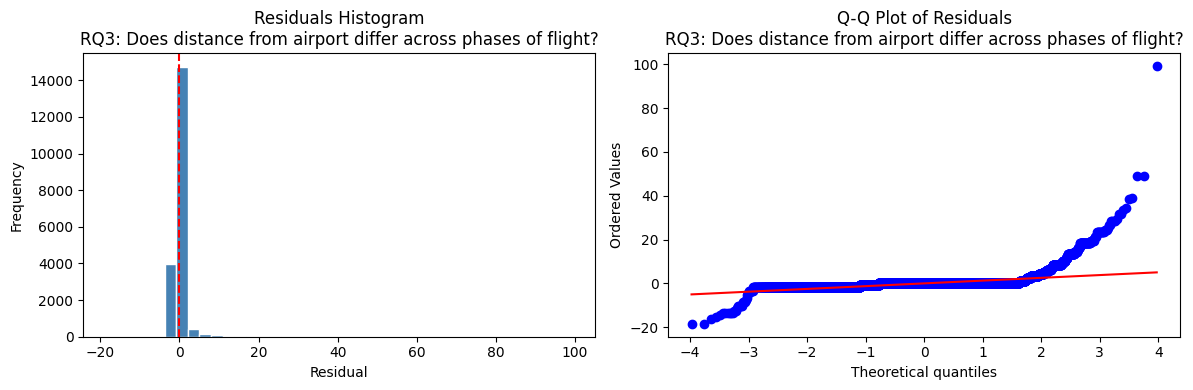

In [18]:
# RQ3: Does distance from airport differ across phases of flight?

run_anova('miles_from_airport', 'when_phase_of_flight', df,
          'RQ3: Does distance from airport differ across phases of flight?')

#### Observations:
•	Descent shows the highest and widest distance spread — median around 18–20 miles with strikes up to 50 miles from the airport, which makes sense as descent begins far from the airport

•	Climb also shows some spread up to ~50 miles, as aircraft gain distance after takeoff

•	Approach has a moderate spread up to ~40 miles, as it begins several miles out from the airport

•	Landing, Landing Roll, Take-off run, Taxi, Parked are all clustered at or near 0 miles, confirming these happen at or very close to the airport

•	Arrival appears as a flat line near 0, indicating very few records in this category

#### Conclusion:
Distance from airport differs significantly across flight phases. Descent and Climb phases involve strikes much farther from the airport, while ground-level phases like Landing Roll, Taxi, and Parked occur right at the airport. This tells us that wildlife strike risk extends well beyond the immediate airport boundary, particularly during descent and climb, suggesting that wildlife management efforts should not be limited to the airport perimeter alone.

